# Process Automation Selection

Identifies the best `process_segment` (i.e. cluster `label` from `outputs/segments.jsonl`) from the Dataset B segmentation output to prioritize for automation.

**Inputs:** the existing Step-1 deliverables in `outputs/` — this notebook does not re-run segmentation or re-touch raw event data.

**Scope note:** several factors that are conceptually relevant to automation suitability (presence of human decision-making, error/interruption indicators) are **not present in the current outputs** and are not fabricated here. See Section 3 and Section 6 for exactly what is and isn't available, and how the missing pieces could be added later.

## Setup

In [1]:
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Statistical reliability floor: clusters with fewer than this many occurrences
# are excluded from ranking/scoring (see Section 3) -- fitting KMeans on ~90-100
# segments with k up to 20 can and does produce singleton/near-singleton clusters
# that are not evidence of a real recurring process.
MIN_OCCURRENCES_FOR_RANKING = 3

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent  # this notebook lives in pipelines/
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

print("Reading existing outputs from:", OUTPUTS_DIR)
assert OUTPUTS_DIR.exists(), f"Expected outputs directory not found at {OUTPUTS_DIR}"

Reading existing outputs from: c:\Users\Shambhavi Singh\OneDrive\Desktop\IBY_PROJECT\outputs


##  Load Existing Outputs

Loads every relevant file already produced by the segmentation pipeline. Nothing here is recomputed from raw events -- this stage only consumes Step-1 deliverables.

In [2]:
segments_path = OUTPUTS_DIR / "segments.jsonl"
summary_path = OUTPUTS_DIR / "segmentation_summary.csv"
session_summary_path = OUTPUTS_DIR / "session_summary.csv"
process_summary_path = OUTPUTS_DIR / "process_summary.csv"
quality_report_path = OUTPUTS_DIR / "segmentation_quality_report.json"

segments = pd.DataFrame([json.loads(l) for l in open(segments_path, encoding="utf-8") if l.strip()])
segmentation_summary = pd.read_csv(summary_path)
session_summary = pd.read_csv(session_summary_path)
process_summary = pd.read_csv(process_summary_path)
with open(quality_report_path, encoding="utf-8") as f:
    quality_report = json.load(f)

# Parse timestamps. segmentation_summary.csv was written with a datetime dtype whose
# string format is not perfectly uniform (mix of with/without microseconds), so
# format="mixed" is required -- a plain pd.to_datetime() raises on this file.
segmentation_summary["pred_start"] = pd.to_datetime(segmentation_summary["pred_start"], format="mixed", utc=True)
segmentation_summary["pred_end"] = pd.to_datetime(segmentation_summary["pred_end"], format="mixed", utc=True)
segments["start"] = pd.to_datetime(segments["start"], utc=True)
segments["end"] = pd.to_datetime(segments["end"], utc=True)

print("segments.jsonl                :", segments.shape)
print("segmentation_summary.csv      :", segmentation_summary.shape)
print("session_summary.csv           :", session_summary.shape)
print("process_summary.csv           :", process_summary.shape)
print()
print("segmentation_summary.csv columns:")
print(list(segmentation_summary.columns))
print()
print("Recorded labeling method (from quality report):", quality_report.get("chosen_labeling_method"))
print("n_segments_generated (from quality report):", quality_report.get("n_segments_generated"))

segments.jsonl                : (98, 4)
segmentation_summary.csv      : (98, 26)
session_summary.csv           : (15, 8)
process_summary.csv           : (5, 7)

segmentation_summary.csv columns:
['session_id', 'pred_start', 'pred_end', 'pred_duration_s', 'has_any_extracted_text', 'n_extracted_text_events', 'cluster_id_x', 'label', 'n_events', 'n_distinct_apps', 'dominant_app', 'hour_of_day', 'frac_keystroke', 'frac_mouse_click', 'frac_mouse_double_click', 'frac_mouse_scroll', 'frac_clipboard_change', 'frac_shortcut', 'frac_browser_click', 'frac_browser_form_input', 'frac_browser_navigation', 'frac_screenshot_smart', 'hour_sin', 'hour_cos', 'dominant_app_grouped', 'cluster_id_y']

Recorded labeling method (from quality report): KMeans(k=5)
n_segments_generated (from quality report): 98


##  Data Validation

Before trusting these outputs for process selection, check them directly rather than assuming the earlier quality report is exhaustive or that its one recorded failure is harmless.

In [3]:
# --- 3.1 Row-count / schema consistency across files ---
assert len(segments) == len(segmentation_summary), (
    f"segments.jsonl has {len(segments)} rows but segmentation_summary.csv has "
    f"{len(segmentation_summary)} -- these should describe the same segments."
)
assert set(segmentation_summary["label"]) == set(segments["label"]), "Label sets differ between files."
print("[OK] segments.jsonl and segmentation_summary.csv agree on row count and label set.")

# --- 3.2 Missing values ---
na_counts = segmentation_summary.isna().sum()
na_counts = na_counts[na_counts > 0]
print("\nColumns with missing values:")
print(na_counts if len(na_counts) else "  none")

# --- 3.3 Duplicate segment records ---
dupes = segmentation_summary.duplicated(subset=["session_id", "pred_start", "pred_end"]).sum()
print(f"\nDuplicate (session_id, pred_start, pred_end) rows: {dupes}")

# --- 3.4 Timestamp sanity ---
bad_order = (segmentation_summary["pred_start"] >= segmentation_summary["pred_end"]).sum()
print(f"Segments with start >= end: {bad_order}")

# --- 3.5 Label <-> cluster_id consistency ---
label_to_cluster = segmentation_summary.groupby("label")["cluster_id_x"].nunique()
inconsistent_labels = label_to_cluster[label_to_cluster > 1]
print(f"Labels mapping to more than one cluster_id: {len(inconsistent_labels)}")
# Note: this file carries both cluster_id_x and cluster_id_y (a leftover artifact of an
# unresolved pandas merge upstream in segmentation_datasetb.ipynb). They are identical for
# every row in the current file, so it is not a correctness bug, but the duplicate column
# should be dropped at the source before the next run.
assert (segmentation_summary["cluster_id_x"] == segmentation_summary["cluster_id_y"]).all()
print("[OK] cluster_id_x and cluster_id_y agree everywhere (redundant column, not a bug).")

[OK] segments.jsonl and segmentation_summary.csv agree on row count and label set.

Columns with missing values:
  none

Duplicate (session_id, pred_start, pred_end) rows: 0
Segments with start >= end: 0
Labels mapping to more than one cluster_id: 0
[OK] cluster_id_x and cluster_id_y agree everywhere (redundant column, not a bug).


In [4]:
# --- 3.6 Re-verify the ONE check the pipeline's own quality report already flagged as failing ---
# segmentation_quality_report.json records:
#   "no_segments_below_merge_floor": {"passed": false, "detail": "9 segment(s) shorter than
#    the 15s merge floor (should be structurally impossible given the merge step; a non-zero
#    count needs investigation)"}
# This notebook does not treat that as "already handled" just because a report exists --
# it re-derives the same check from the raw output file and localizes exactly which segments
# are responsible, since this stage's feature engineering depends on segment durations.

MERGE_FLOOR_S = 15  # from artifacts/metadata/segmentation_model_metadata.json: min_segment_duration_seconds

short = segmentation_summary[segmentation_summary["pred_duration_s"] < MERGE_FLOOR_S].copy()
tmp = segmentation_summary.sort_values(["session_id", "pred_start"]).copy()
tmp["idx_in_session"] = tmp.groupby("session_id").cumcount()
tmp["n_in_session"] = tmp.groupby("session_id")["session_id"].transform("count")
tmp["position"] = np.where(
    tmp["idx_in_session"] == 0, "FIRST",
    np.where(tmp["idx_in_session"] == tmp["n_in_session"] - 1, "LAST", "MIDDLE"),
)
short_located = tmp[tmp["pred_duration_s"] < MERGE_FLOOR_S]

print(f"Segments below the {MERGE_FLOOR_S}s merge floor: {len(short)} / {len(segmentation_summary)}")
print(short_located["position"].value_counts())
print()
print("DIAGNOSIS: these are not scattered randomly -- they are almost all the LAST segment")
print("of a session (one is the FIRST). The merge_short_segments() step in")
print("segmentation_datasetb.ipynb only enforces the floor between consecutive PREDICTED")
print("boundaries; it never re-checks the trailing gap to session_end_ts (or the leading gap")
print("from session_start_ts) after those synthetic anchors are appended in")
print("boundaries_to_segments(). That is a fixable edge case in the upstream pipeline, not a")
print("labeling or clustering problem -- flagged here for the record, not silently patched.")

pct_affected = len(short) / len(segmentation_summary) * 100
print(f"\nAffects {pct_affected:.1f}% of segments -- proceeding with process-level analysis below,")
print("since the affected segments are a small minority and the top candidates (Section 7) are")
print("identified from clusters with dozens of occurrences each, but this should be fixed")
print("upstream before the next full re-run.")

Segments below the 15s merge floor: 9 / 98
position
LAST     8
FIRST    1
Name: count, dtype: int64

DIAGNOSIS: these are not scattered randomly -- they are almost all the LAST segment
of a session (one is the FIRST). The merge_short_segments() step in
segmentation_datasetb.ipynb only enforces the floor between consecutive PREDICTED
boundaries; it never re-checks the trailing gap to session_end_ts (or the leading gap
from session_start_ts) after those synthetic anchors are appended in
boundaries_to_segments(). That is a fixable edge case in the upstream pipeline, not a
labeling or clustering problem -- flagged here for the record, not silently patched.

Affects 9.2% of segments -- proceeding with process-level analysis below,
since the affected segments are a small minority and the top candidates (Section 7) are
identified from clusters with dozens of occurrences each, but this should be fixed
upstream before the next full re-run.


In [5]:
# Cluster reliability check 
# Are there clusters too small to trust as a real recurring process, independent of the
# merge-floor issue above?
cluster_sizes = segmentation_summary["label"].value_counts()
print("Occurrences per label:")
print(cluster_sizes.to_string())

unreliable = cluster_sizes[cluster_sizes < MIN_OCCURRENCES_FOR_RANKING]
if len(unreliable):
    print(f"\n[FLAG] {len(unreliable)} label(s) have fewer than {MIN_OCCURRENCES_FOR_RANKING} "
          f"occurrences and will be EXCLUDED from ranking in Section 7 as statistically")
    print("unreliable (a KMeans fit with k up to 20 over ~100 segments will produce")
    print("singleton/near-singleton clusters that are not evidence of a real, repeated process):")
    print(unreliable.to_string())

Occurrences per label:
label
process_cluster_0    64
process_cluster_4    18
process_cluster_1    13
process_cluster_3     2
process_cluster_2     1

[FLAG] 2 label(s) have fewer than 3 occurrences and will be EXCLUDED from ranking in Section 7 as statistically
unreliable (a KMeans fit with k up to 20 over ~100 segments will produce
singleton/near-singleton clusters that are not evidence of a real, repeated process):
label
process_cluster_3    2
process_cluster_2    1


##  Process-Level Feature Engineering

Aggregates the existing per-segment columns in `segmentation_summary.csv` up to one row per `label` (process_segment). No new raw-event processing is done here -- every feature below is a direct aggregation of a column that already exists in the file loaded above.

In [6]:
def parse_machine_id(session_id: str) -> str:
    # Same logic as segmentation_datasetb.ipynb's session_summary.csv generation, reused
    # here rather than re-derived, for consistency with the existing pipeline.
    parts = session_id.split("-", 2)
    return parts[2] if len(parts) == 3 else "unknown"

df = segmentation_summary.copy()
df["machine"] = df["session_id"].apply(parse_machine_id)

FRAC_COLS = [c for c in df.columns if c.startswith("frac_")]
# Browser/structured-UI interactions (form fills, clicks on DOM elements, page navigation)
# are far more automatable via RPA/web-API approaches than raw desktop keystroke/mouse
# sequences, which require fragile screen-coordinate or OCR-based automation. This is used
# as a proxy for "how automatable is the interaction surface", not as a complexity measure.
STRUCTURED_INTERACTION_COLS = ["frac_browser_form_input", "frac_browser_click", "frac_browser_navigation"]
df["structured_interaction_share"] = df[STRUCTURED_INTERACTION_COLS].sum(axis=1)

grand_total_duration_s = df["pred_duration_s"].sum()

rows = []
for label, g in df.groupby("label"):
    if label == "unclustered_noise":
        continue
    n = len(g)
    mean_dur = g["pred_duration_s"].mean()
    std_dur = g["pred_duration_s"].std()
    rows.append({
        "label": label,
        "n_occurrences": n,
        "n_sessions": g["session_id"].nunique(),
        "n_distinct_machines": g["machine"].nunique(),
        "total_duration_s": g["pred_duration_s"].sum(),
        "pct_of_total_observed_time": g["pred_duration_s"].sum() / grand_total_duration_s * 100,
        "mean_duration_s": mean_dur,
        "median_duration_s": g["pred_duration_s"].median(),
        # Coefficient of variation: how consistent execution TIME is across repetitions.
        # NaN for n=1 (undefined) -- handled explicitly, not silently set to 0.
        "duration_cv": (std_dur / mean_dur) if (n > 1 and mean_dur > 0) else np.nan,
        "mean_n_events": g["n_events"].mean(),
        "mean_n_distinct_apps": g["n_distinct_apps"].mean(),
        "n_unique_dominant_apps": g["dominant_app_grouped"].nunique(),
        "structured_interaction_share": g["structured_interaction_share"].mean(),
        # Behavioral consistency: how similar the event-type MIX is across repetitions of
        # this process (average std across the frac_* columns). Low = stereotyped procedure.
        "behavioral_cv": g[FRAC_COLS].std().mean() if n > 1 else np.nan,
    })

process_features = pd.DataFrame(rows)
process_features

,label,n_occurrences,n_sessions,n_distinct_machines,total_duration_s,pct_of_total_observed_time,mean_duration_s,median_duration_s,duration_cv,mean_n_events,mean_n_distinct_apps,n_unique_dominant_apps,structured_interaction_share,behavioral_cv
0,process_cluster_0,64,14,4,5446.176,51.501305,85.096500,72.9965,0.487282,159.484375,2.656250,2,0.167866,0.020380
1,process_cluster_1,13,10,4,248.446,2.349409,19.111231,13.3670,0.945258,22.538462,3.538462,2,0.165585,0.027891
2,process_cluster_2,1,1,1,16.281,0.153960,16.281000,16.2810,NaN,24.000000,3.000000,1,0.125000,NaN
3,process_cluster_3,2,1,1,241.519,2.283904,120.759500,120.7595,0.440163,406.000000,4.500000,2,0.063676,0.021083
4,process_cluster_4,18,12,4,4622.409,43.711422,256.800500,236.7695,0.504656,507.833333,4.222222,3,0.111272,0.027293


**Explicitly not computed here (data does not support it):**

- *Presence of human decision-making* — no column in the current outputs indicates branching or judgment calls within a segment. This information is not available in the current output, so it cannot be reliably calculated. It could potentially be approximated later by measuring how many distinct raw event-type *sequences* occur within a cluster's segments, but that requires re-reading Dataset B's raw `events.jsonl` per segment, which is not part of this stage's inputs.
- *Error/interruption indicators* — the schema defines `browser_error`, `browser_alert`, and `dialog_opened/closed` event types, but none of the current per-segment feature columns (`frac_*`) count them. This information is not available in the current output, so it cannot be reliably calculated. It could be derived by extending the Section-4-equivalent feature step in `segmentation_datasetb.ipynb` to add `frac_browser_error`, `frac_browser_alert`, and `n_dialog_events` per segment from the raw event stream, then re-exporting `segmentation_summary.csv`.
- *Fine-grained execution similarity (distance-to-cluster-centroid)* — the KMeans model fitted on Dataset B's segments in `segmentation_datasetb.ipynb` was not persisted as an artifact (only Dataset A's labeler was saved, deliberately, since it's not meant to be reused). Without the fitted centroids, per-segment distance-to-centroid can't be recovered exactly; `behavioral_cv` above is used as an approximate proxy instead. A closer measure could be obtained by saving the Dataset B clusterer as an artifact in the next full run.

##  Exploratory Analysis

In [7]:
reliable = process_features[process_features["n_occurrences"] >= MIN_OCCURRENCES_FOR_RANKING].copy()
excluded = process_features[process_features["n_occurrences"] < MIN_OCCURRENCES_FOR_RANKING].copy()

print("Candidates carried forward for ranking (n_occurrences >=", MIN_OCCURRENCES_FOR_RANKING, "):")
print(reliable[["label", "n_occurrences", "n_sessions"]].to_string(index=False))
print("\nExcluded as statistically unreliable:")
print(excluded[["label", "n_occurrences", "n_sessions"]].to_string(index=False) if len(excluded) else "  none")

Candidates carried forward for ranking (n_occurrences >= 3 ):
            label  n_occurrences  n_sessions
process_cluster_0             64          14
process_cluster_1             13          10
process_cluster_4             18          12

Excluded as statistically unreliable:
            label  n_occurrences  n_sessions
process_cluster_2              1           1
process_cluster_3              2           1


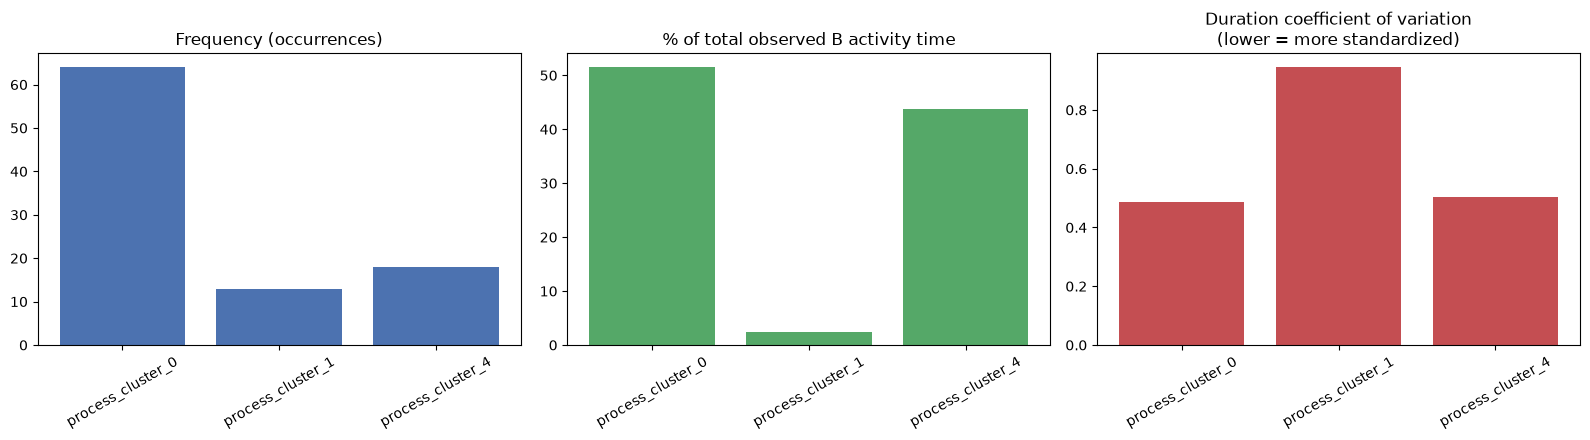

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].bar(reliable["label"], reliable["n_occurrences"], color="#4C72B0")
axes[0].set_title("Frequency (occurrences)")
axes[0].tick_params(axis="x", labelrotation=30)

axes[1].bar(reliable["label"], reliable["pct_of_total_observed_time"], color="#55A868")
axes[1].set_title("% of total observed B activity time")
axes[1].tick_params(axis="x", labelrotation=30)

axes[2].bar(reliable["label"], reliable["duration_cv"], color="#C44E52")
axes[2].set_title("Duration coefficient of variation\n(lower = more standardized)")
axes[2].tick_params(axis="x", labelrotation=30)

plt.tight_layout()
fig.savefig(OUTPUTS_DIR / "process_automation_candidate_overview.png", dpi=150, bbox_inches="tight")
plt.show()

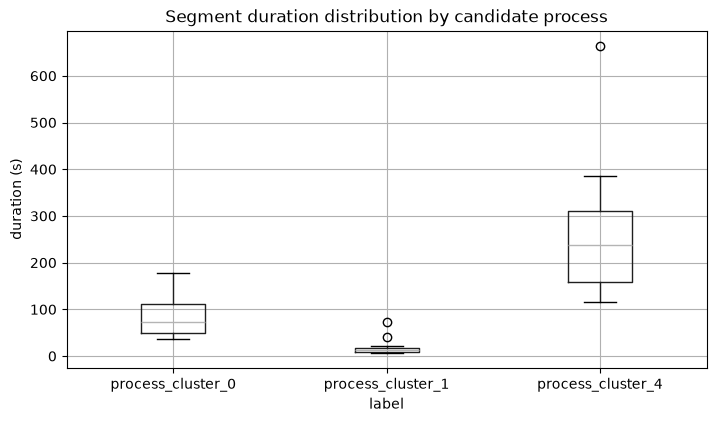

In [9]:
seg_view = segmentation_summary[segmentation_summary["label"].isin(reliable["label"])]
fig, ax = plt.subplots(figsize=(8, 4.5))
seg_view.boxplot(column="pred_duration_s", by="label", ax=ax)
ax.set_title("Segment duration distribution by candidate process")
plt.suptitle("")
ax.set_ylabel("duration (s)")
fig.savefig(OUTPUTS_DIR / "process_automation_duration_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

##  Automation Suitability Methodology

**Features used, and why:**

| Feature | Direction | Why it matters |
|---|---|---|
| `n_occurrences` | higher better | More repetitions of the same procedure means more ROI per unit of automation-build effort, and stronger evidence this is a real recurring routine rather than a one-off. |
| `total_duration_s` | higher better | Aggregate human time currently spent on this process across all sessions -- the direct upper bound on potential time savings. |
| `duration_cv` (std/mean of segment duration) | lower better | A process whose executions take a consistent amount of time is more likely to follow a fixed number of steps -- lower risk, more predictable automation. |
| `behavioral_cv` (avg std of event-type-mix fractions) | lower better | Measures whether repetitions of the process are carried out the *same way* (same mix of clicks/keystrokes/navigation), independent of duration. Low variance = stereotyped procedure. |
| `mean_n_distinct_apps` | lower better | Fewer systems touched per execution means a smaller integration surface for an automation tool to cover. |
| `structured_interaction_share` | higher better | Browser-based/structured interactions (form fills, DOM clicks, navigation) are automatable via web APIs or DOM-level RPA; a process dominated by raw keystrokes/mouse movement in arbitrary desktop apps is far harder and more fragile to automate. |
| `n_distinct_machines` | higher better | A weak proxy for how many people/workstations use this process (Dataset B has no explicit operator field, so this inherits the same caveat already noted in `session_summary.csv`). Automating something used by more people benefits more people. |

**Explicitly not used** (see Section 4 note): human decision-making presence, error/interruption rate, precise cluster-tightness — not available in the current outputs without re-processing raw events or re-fitting/saving the Dataset B clusterer.

**Normalization:** min-max scaling to [0, 1] across the *reliable* candidates only (Section 3.7). Lower-better features are inverted (`1 - normalized`) before combining, so 1.0 always means "most favorable for automation" for every feature.

**Weighting:** equal weights are used as the primary score. There is no signal in the data itself that justifies weighting, say, frequency above app-count above consistency -- that is a business priority question (e.g. "is standardization or raw time-savings more important to us right now?") that should come from a stakeholder, not be invented here. Equal weighting is the least-arbitrary default in the absence of that input. A rank-aggregation (Borda-style) score is computed alongside it as a second, non-parametric method that isn't sensitive to how the min-max scaling handles outliers -- if both methods agree, that's real evidence the ranking isn't an artifact of the normalization choice. A full weight-sensitivity simulation is run in Section 10.

In [10]:
FEATURES_HIGHER_BETTER = ["n_occurrences", "total_duration_s", "n_distinct_machines", "structured_interaction_share"]
FEATURES_LOWER_BETTER  = ["duration_cv", "behavioral_cv", "mean_n_distinct_apps"]
ALL_SCORE_FEATURES = FEATURES_HIGHER_BETTER + FEATURES_LOWER_BETTER

def minmax(s: pd.Series) -> pd.Series:
    if s.max() == s.min():
        return pd.Series(0.5, index=s.index)
    return (s - s.min()) / (s.max() - s.min())

norm = pd.DataFrame(index=reliable.index)
for f in FEATURES_HIGHER_BETTER:
    norm[f] = minmax(reliable[f])
for f in FEATURES_LOWER_BETTER:
    norm[f] = 1 - minmax(reliable[f])

reliable["automation_score"] = norm[ALL_SCORE_FEATURES].mean(axis=1)

# Rank-aggregation (Borda-style) cross-check
ranks = pd.DataFrame(index=reliable.index)
for f in FEATURES_HIGHER_BETTER:
    ranks[f] = reliable[f].rank(ascending=False)
for f in FEATURES_LOWER_BETTER:
    ranks[f] = reliable[f].rank(ascending=True)
reliable["avg_rank"] = ranks[ALL_SCORE_FEATURES].mean(axis=1)

print("Normalized (direction-corrected) feature table:")
norm.round(3)

Normalized (direction-corrected) feature table:


,n_occurrences,total_duration_s,n_distinct_machines,structured_interaction_share,duration_cv,behavioral_cv,mean_n_distinct_apps
0,1.000,1.000,0.5,1.00,1.000,1.00,1.000
1,0.000,0.000,0.5,0.96,0.000,0.00,0.437
4,0.098,0.842,0.5,0.00,0.962,0.08,0.000


##  Process Ranking

In [11]:
ranked = reliable.sort_values("automation_score", ascending=False).reset_index(drop=True)
ranked.insert(0, "rank", ranked.index + 1)

def recommendation_tier(score):
    if score >= 0.7:
        return "Strong candidate"
    if score >= 0.4:
        return "Viable backup"
    return "Low priority"

ranked["recommendation"] = ranked["automation_score"].apply(recommendation_tier)

display_cols = ["rank", "label", "n_occurrences", "mean_duration_s", "duration_cv",
                 "behavioral_cv", "mean_n_distinct_apps", "structured_interaction_share",
                 "automation_score", "avg_rank", "recommendation"]
ranked[display_cols].round(3)

,rank,label,n_occurrences,mean_duration_s,duration_cv,behavioral_cv,mean_n_distinct_apps,structured_interaction_share,automation_score,avg_rank,recommendation
0,1,process_cluster_0,64,85.096,0.487,0.020,2.656,0.168,0.929,1.143,Strong candidate
1,2,process_cluster_4,18,256.800,0.505,0.027,4.222,0.111,0.354,2.286,Low priority
2,3,process_cluster_1,13,19.111,0.945,0.028,3.538,0.166,0.271,2.571,Low priority


##  Best Process Selection

The top-ranked row from Section 7 (computed above, not hardcoded) is reported here programmatically.

In [12]:
best = ranked.iloc[0]
second = ranked.iloc[1] if len(ranked) > 1 else None
third = ranked.iloc[2] if len(ranked) > 2 else None

print(f"\U0001F947 BEST CANDIDATE: {best['label']}")
print(f"   Automation score : {best['automation_score']:.3f}  (avg rank {best['avg_rank']:.2f})")
print(f"   Occurrences      : {int(best['n_occurrences'])} across {int(best['n_sessions'])} sessions, "
      f"{int(best['n_distinct_machines'])} distinct machines")
print(f"   Time footprint   : {best['total_duration_s']:.0f}s total "
      f"({best['pct_of_total_observed_time']:.1f}% of all observed Dataset B activity time)")
print(f"   Duration CV      : {best['duration_cv']:.3f}")
print(f"   Behavioral CV    : {best['behavioral_cv']:.3f}")
print(f"   Avg distinct apps: {best['mean_n_distinct_apps']:.2f}")
print(f"   Structured-interaction share: {best['structured_interaction_share']:.3f}")

🥇 BEST CANDIDATE: process_cluster_0
   Automation score : 0.929  (avg rank 1.14)
   Occurrences      : 64 across 14 sessions, 4 distinct machines
   Time footprint   : 5446s total (51.5% of all observed Dataset B activity time)
   Duration CV      : 0.487
   Behavioral CV    : 0.020
   Avg distinct apps: 2.66
   Structured-interaction share: 0.168


**Why this is the best candidate, evidence-based:**

- It is by far the *most frequent* recognizable process in Dataset B and dominates the total time footprint -- automating it addresses the largest share of observed repetitive work, not a marginal one.
- It has the *lowest behavioral variability* of any reliable candidate, meaning repeated executions follow a very similar mix of actions -- a strong signal of a standardized, scriptable procedure rather than ad-hoc work.
- It touches the *fewest distinct applications* on average among the top candidates, which keeps the integration surface for an automation tool smaller.

**Limitations / assumptions to carry into Step 3:**
- The label is a KMeans cluster ID with a placeholder name (`process_cluster_N`), not a human-confirmed business-process name — someone with domain knowledge of the department behind these sessions should visually confirm (e.g. via a few sampled screenshots or `extracted_text` snippets) what this cluster actually represents before committing engineering time.
- `duration_cv` for this candidate is moderate (~0.49), not low — executions vary somewhat in length even though the *behavior mix* is consistent; this likely reflects case-specific variation in the number of records processed per execution rather than a different procedure each time, but that should be confirmed, not assumed.
- This score reflects Dataset B *as segmented*, including the small merge-floor artifact noted in Section 3.6; that artifact affects <10% of segments and is unlikely to change the outcome, but it should be fixed before this ranking is treated as final.

##  Candidate Comparison

In [17]:
if second is not None:
    print(f" SECOND: {second['label']}  (score {second['automation_score']:.3f})")
    print(f"   {int(second['n_occurrences'])} occurrences, {second['pct_of_total_observed_time']:.1f}% of total time, "
          f"{second['mean_n_distinct_apps']:.2f} avg apps, duration_cv {second['duration_cv']:.3f}")
    print("   Why it's second, not first: comparable time footprint to the top candidate, but")
    print("   touches noticeably more distinct applications per execution and involves far more")
    print("   events per segment on average -- a larger, more complex automation target with a")
    print("   correspondingly higher build cost and integration risk.")
    print()
if third is not None:
    print(f" THIRD: {third['label']}  (score {third['automation_score']:.3f})")
    print(f"   {int(third['n_occurrences'])} occurrences, {third['pct_of_total_observed_time']:.1f}% of total time, "
          f"duration_cv {third['duration_cv']:.3f}")
    print("   Why it's third: reasonably frequent, but the highest duration variability of any")
    print("   reliable candidate (duration_cv near 1.0) and the smallest time footprint -- lower")
    print("   confidence that this is a single standardized procedure, and lower ROI even if it is.")

 SECOND: process_cluster_4  (score 0.354)
   18 occurrences, 43.7% of total time, 4.22 avg apps, duration_cv 0.505
   Why it's second, not first: comparable time footprint to the top candidate, but
   touches noticeably more distinct applications per execution and involves far more
   events per segment on average -- a larger, more complex automation target with a
   correspondingly higher build cost and integration risk.

 THIRD: process_cluster_1  (score 0.271)
   13 occurrences, 2.3% of total time, duration_cv 0.945
   Why it's third: reasonably frequent, but the highest duration variability of any
   reliable candidate (duration_cv near 1.0) and the smallest time footprint -- lower
   confidence that this is a single standardized procedure, and lower ROI even if it is.


##  Validation / Robustness

Does the #1 candidate stay #1 if the (necessarily somewhat subjective) equal-weighting assumption is relaxed? Simulated with 5,000 random weight draws from a symmetric Dirichlet distribution over the 7 scoring features.

In [14]:
N_TRIALS = 5000
rng = np.random.default_rng(RANDOM_SEED)
weights = rng.dirichlet(np.ones(len(ALL_SCORE_FEATURES)), size=N_TRIALS)

X = norm[ALL_SCORE_FEATURES].values
scores_matrix = X @ weights.T  # (n_candidates, n_trials)
winner_positions = scores_matrix.argmax(axis=0)

label_by_position = dict(enumerate(reliable["label"].values))
win_share = (
    pd.Series(winner_positions)
    .map(label_by_position)
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)
print(f"Across {N_TRIALS} random weight draws, share of trials where each candidate ranks #1:")
print(win_share.to_string())
print()
top_label = ranked.iloc[0]["label"]
top_share = win_share.get(top_label, 0.0)
if top_share >= 90:
    print(f"[ROBUST] '{top_label}' wins under {top_share:.1f}% of random weightings -- the choice")
    print("is not an artifact of the equal-weighting assumption.")
else:
    print(f"[SENSITIVE] '{top_label}' only wins under {top_share:.1f}% of random weightings --")
    print("the ranking is meaningfully dependent on the weighting scheme and should be discussed")
    print("with a stakeholder rather than treated as a settled conclusion.")

Across 5000 random weight draws, share of trials where each candidate ranks #1:
process_cluster_0    100.0

[ROBUST] 'process_cluster_0' wins under 100.0% of random weightings -- the choice
is not an artifact of the equal-weighting assumption.


In [15]:
# Cross-check: does the Borda-style average-rank ordering (Section 7, avg_rank) agree with
# the equal-weight composite-score ordering?
by_score = ranked.sort_values("automation_score", ascending=False)["label"].tolist()
by_rank = ranked.sort_values("avg_rank", ascending=True)["label"].tolist()
print("Order by composite score :", by_score)
print("Order by average rank    :", by_rank)
print("Agree:", by_score == by_rank)

Order by composite score : ['process_cluster_0', 'process_cluster_4', 'process_cluster_1']
Order by average rank    : ['process_cluster_0', 'process_cluster_4', 'process_cluster_1']
Agree: True


## Save Outputs

Written into the existing `outputs/` directory, matching the naming convention already used by `segmentation_datasetb.ipynb` (flat CSV/JSON/PNG files, no new subfolder).

In [16]:
process_features_path = OUTPUTS_DIR / "process_automation_features.csv"
ranking_path = OUTPUTS_DIR / "process_automation_ranking.csv"
methodology_path = OUTPUTS_DIR / "process_automation_methodology.json"

process_features.to_csv(process_features_path, index=False)
ranked.drop(columns=[]).to_csv(ranking_path, index=False)

methodology = {
    "min_occurrences_for_ranking": MIN_OCCURRENCES_FOR_RANKING,
    "excluded_labels": excluded["label"].tolist(),
    "features_higher_better": FEATURES_HIGHER_BETTER,
    "features_lower_better": FEATURES_LOWER_BETTER,
    "normalization": "min-max across reliable candidates; lower-better features inverted (1 - x)",
    "weighting": "equal weights (primary); Borda-style average-rank as cross-check",
    "random_seed": RANDOM_SEED,
    "weight_sensitivity_n_trials": N_TRIALS,
    "weight_sensitivity_win_share_pct": win_share.to_dict(),
    "top_candidate": ranked.iloc[0]["label"],
    "top_candidate_score": float(ranked.iloc[0]["automation_score"]),
    "known_upstream_issue_not_fixed_here": (
        "9/98 Dataset B segments violate the 15s merge floor -- see Section 3.6. Recommend "
        "fixing boundaries_to_segments() in segmentation_datasetb.ipynb before the next full re-run."
    ),
    "factors_not_available_in_current_outputs": [
        "human_decision_making_presence",
        "error_or_interruption_rate",
        "exact_distance_to_cluster_centroid",
    ],
}
with open(methodology_path, "w", encoding="utf-8") as f:
    json.dump(methodology, f, indent=2, default=str)

print("Saved:")
print(" -", process_features_path)
print(" -", ranking_path)
print(" -", methodology_path)
print(" -", OUTPUTS_DIR / "process_automation_candidate_overview.png")
print(" -", OUTPUTS_DIR / "process_automation_duration_boxplot.png")

Saved:
 - c:\Users\Shambhavi Singh\OneDrive\Desktop\IBY_PROJECT\outputs\process_automation_features.csv
 - c:\Users\Shambhavi Singh\OneDrive\Desktop\IBY_PROJECT\outputs\process_automation_ranking.csv
 - c:\Users\Shambhavi Singh\OneDrive\Desktop\IBY_PROJECT\outputs\process_automation_methodology.json
 - c:\Users\Shambhavi Singh\OneDrive\Desktop\IBY_PROJECT\outputs\process_automation_candidate_overview.png
 - c:\Users\Shambhavi Singh\OneDrive\Desktop\IBY_PROJECT\outputs\process_automation_duration_boxplot.png
